# Frozen embedding benchmark

Compare ESMC-6B, ESM2-650M, and SaProt-650M embeddings using one cluster-aware split and one balanced linear probe. The primary metric is held-out macro-F1. PCA and clustering metrics are descriptive supporting analyses.

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler

from rbpdetect2.benchmarking import (
    LABELS,
    embedding_separation_metrics,
    load_embedding_bundle,
    load_or_create_split,
    run_linear_probe,
    validate_bundle_against_split,
)

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "pyproject.toml").exists():
            return candidate.resolve()
    raise RuntimeError("Run this notebook from the rbpdetect2 repository")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
EMBEDDING_DIR = ROOT / "benchmarks" / "embeddings"
RESULTS_DIR = ROOT / "benchmarks" / "results"
SPLIT_PATH = ROOT / "benchmarks" / "splits" / "split_seed42.tsv"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIRS = {
    "ESMC-6B": EMBEDDING_DIR / "esmc-6b",
    "ESM2-650M": EMBEDDING_DIR / "esm2-650m",
    "SaProt-650M": EMBEDDING_DIR / "saprot-650m",
}
COLORS = {"TF": "#e74c3c", "TSP": "#3498db", "nonRBP": "#2ecc71"}
C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
sns.set_theme(style="whitegrid", context="notebook")

## Load embedding bundles and align to the common protein set

SaProt only covers sequences with a predicted structure, so the three models do not span identical proteins. To keep scores comparable, the benchmark uses the **intersection of IDs present in all three bundles** and aligns every bundle to that set. Integrity is checked per shared ID (matching label and sequence hash) instead of requiring identical dataset hashes.

In [4]:
bundles = {}
for model_name, bundle_dir in MODEL_DIRS.items():
    embeddings, ids, metadata = load_embedding_bundle(bundle_dir)
    bundles[model_name] = {"embeddings": embeddings, "ids": ids, "metadata": metadata}

# Models cover different proteins (SaProt is limited to sequences with a
# predicted structure). Benchmark on the intersection so every model is scored
# on the same proteins, then align each bundle (embeddings + ids) to it.
common_ids = sorted(set.intersection(*(set(b["ids"]["id"]) for b in bundles.values())))
print("Per-model IDs: " + ", ".join(f"{m}={len(b['ids'])}" for m, b in bundles.items()))
print(f"Intersection used for benchmark: {len(common_ids)} proteins")
if not common_ids:
    raise ValueError("Embedding bundles share no common IDs")

for bundle in bundles.values():
    row_lookup = pd.Series(np.arange(len(bundle["ids"])), index=bundle["ids"]["id"])
    keep = row_lookup.loc[common_ids].to_numpy()
    bundle["embeddings"] = bundle["embeddings"][keep]
    bundle["ids"] = bundle["ids"].iloc[keep].reset_index(drop=True)

# Integrity: every model must agree on label + sequence hash for the shared IDs.
reference = bundles[next(iter(bundles))]["ids"].set_index("id").loc[common_ids, ["label", "sequence_sha256"]]
for model_name, bundle in bundles.items():
    check = bundle["ids"].set_index("id").loc[common_ids, ["label", "sequence_sha256"]]
    if not check.equals(reference):
        raise ValueError(f"{model_name} disagrees on label/sequence for the shared IDs")

bundle_summary = pd.DataFrame([
    {
        "model": model_name,
        "n_sequences_total": bundle["metadata"]["n_sequences"],
        "n_sequences_benchmarked": len(bundle["ids"]),
        "embedding_dim": bundle["metadata"]["embedding_dim"],
        "resolved_revision": bundle["metadata"].get("resolved_revision"),
        "elapsed_minutes": bundle["metadata"]["elapsed_seconds"] / 60,
        "peak_gpu_memory_gb": (bundle["metadata"].get("peak_gpu_memory_bytes") or np.nan) / 1e9,
    }
    for model_name, bundle in bundles.items()
])
display(bundle_summary)

Per-model IDs: ESMC-6B=3154, ESM2-650M=3154, SaProt-650M=2893
Intersection used for benchmark: 2893 proteins


,model,n_sequences_total,n_sequences_benchmarked,embedding_dim,resolved_revision,elapsed_minutes,peak_gpu_memory_gb
0,ESMC-6B,3154,2893,2560,45b0fa5d7fb06faefbd5e3b89bdcef35d564e79a,11.179299,14.139781
1,ESM2-650M,3154,2893,1280,08e4846e537177426273712802403f7ba8261b6c,2.166542,1.578713
2,SaProt-650M,2893,2893,1280,d9b9ad00ef61c0990e611b2b43f2231c7de24b38,1.756857,1.580705


## Create or load the shared split

The split clusters all classes together with MMseqs2 at 30% identity. The generated TSV should be committed and reused for every benchmark run.

In [5]:
split = load_or_create_split(
    data_dir=DATA_DIR,
    split_path=SPLIT_PATH,
    min_seq_id=0.30,
    coverage=0.80,
    val_fraction=0.15,
    test_fraction=0.15,
    seed=42,
)
# The committed split spans every labeled protein; restrict it to the
# benchmarked intersection so probe/validation operate on the common set.
split = split[split["id"].isin(common_ids)].reset_index(drop=True)
for model_name, bundle in bundles.items():
    validate_bundle_against_split(bundle["ids"], split, model_name)

display(split.groupby(["split", "label"]).size().unstack(fill_value=0))
mixed_clusters = split.groupby("cluster")["label"].nunique().gt(1).sum()
print(f"Clusters containing more than one class: {mixed_clusters}")

label,TF,TSP,nonRBP
split,,,
test,101,119,204
train,441,694,945
val,64,119,206


Clusters containing more than one class: 0


## Linear probe and high-dimensional separation metrics

The balanced multinomial logistic-regression probe tunes regularization on validation macro-F1, then refits on train plus validation data and evaluates the test set once. Confidence intervals resample complete test clusters.

In [6]:
result_rows = []
prediction_frames = []

for model_name, bundle in bundles.items():
    metrics, predictions = run_linear_probe(
        embeddings=bundle["embeddings"],
        ids=bundle["ids"],
        split=split,
        c_values=C_VALUES,
        bootstrap_replicates=2000,
        bootstrap_seed=42,
    )
    metrics.update(embedding_separation_metrics(
        embeddings=bundle["embeddings"],
        ids=bundle["ids"],
        split=split,
    ))
    validation_scores = metrics.pop("validation_scores")
    result_rows.append({
        "model": model_name,
        **metrics,
        "validation_scores_json": json.dumps(validation_scores, sort_keys=True),
        "model_id": bundle["metadata"]["model_id"],
        "resolved_revision": bundle["metadata"].get("resolved_revision"),
        "embedding_dim": bundle["metadata"]["embedding_dim"],
    })
    predictions.insert(0, "model", model_name)
    prediction_frames.append(predictions)

results = pd.DataFrame(result_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
predictions = pd.concat(prediction_frames, ignore_index=True)
results.to_csv(RESULTS_DIR / "linear_probe_metrics.csv", index=False)
predictions.to_csv(RESULTS_DIR / "test_predictions.tsv", sep="\t", index=False)

display(results[[
    "model", "macro_f1", "macro_f1_ci_low", "macro_f1_ci_high",
    "balanced_accuracy", "mcc", "cosine_silhouette", "5nn_balanced_accuracy", "best_c",
]].round(3))

,model,macro_f1,macro_f1_ci_low,macro_f1_ci_high,balanced_accuracy,mcc,cosine_silhouette,5nn_balanced_accuracy,best_c
0,SaProt-650M,0.988,0.970,0.998,0.990,0.981,0.324,0.976,0.010
1,ESMC-6B,0.979,0.953,0.991,0.982,0.967,0.230,0.968,0.001
2,ESM2-650M,0.977,0.949,0.991,0.982,0.967,0.175,0.973,0.001


## Main benchmark figure

PCA is fit using standardized training embeddings only, then applied to the held-out test proteins. Silhouette and 5-NN metrics are calculated in the original embedding space, not on the PCA coordinates.

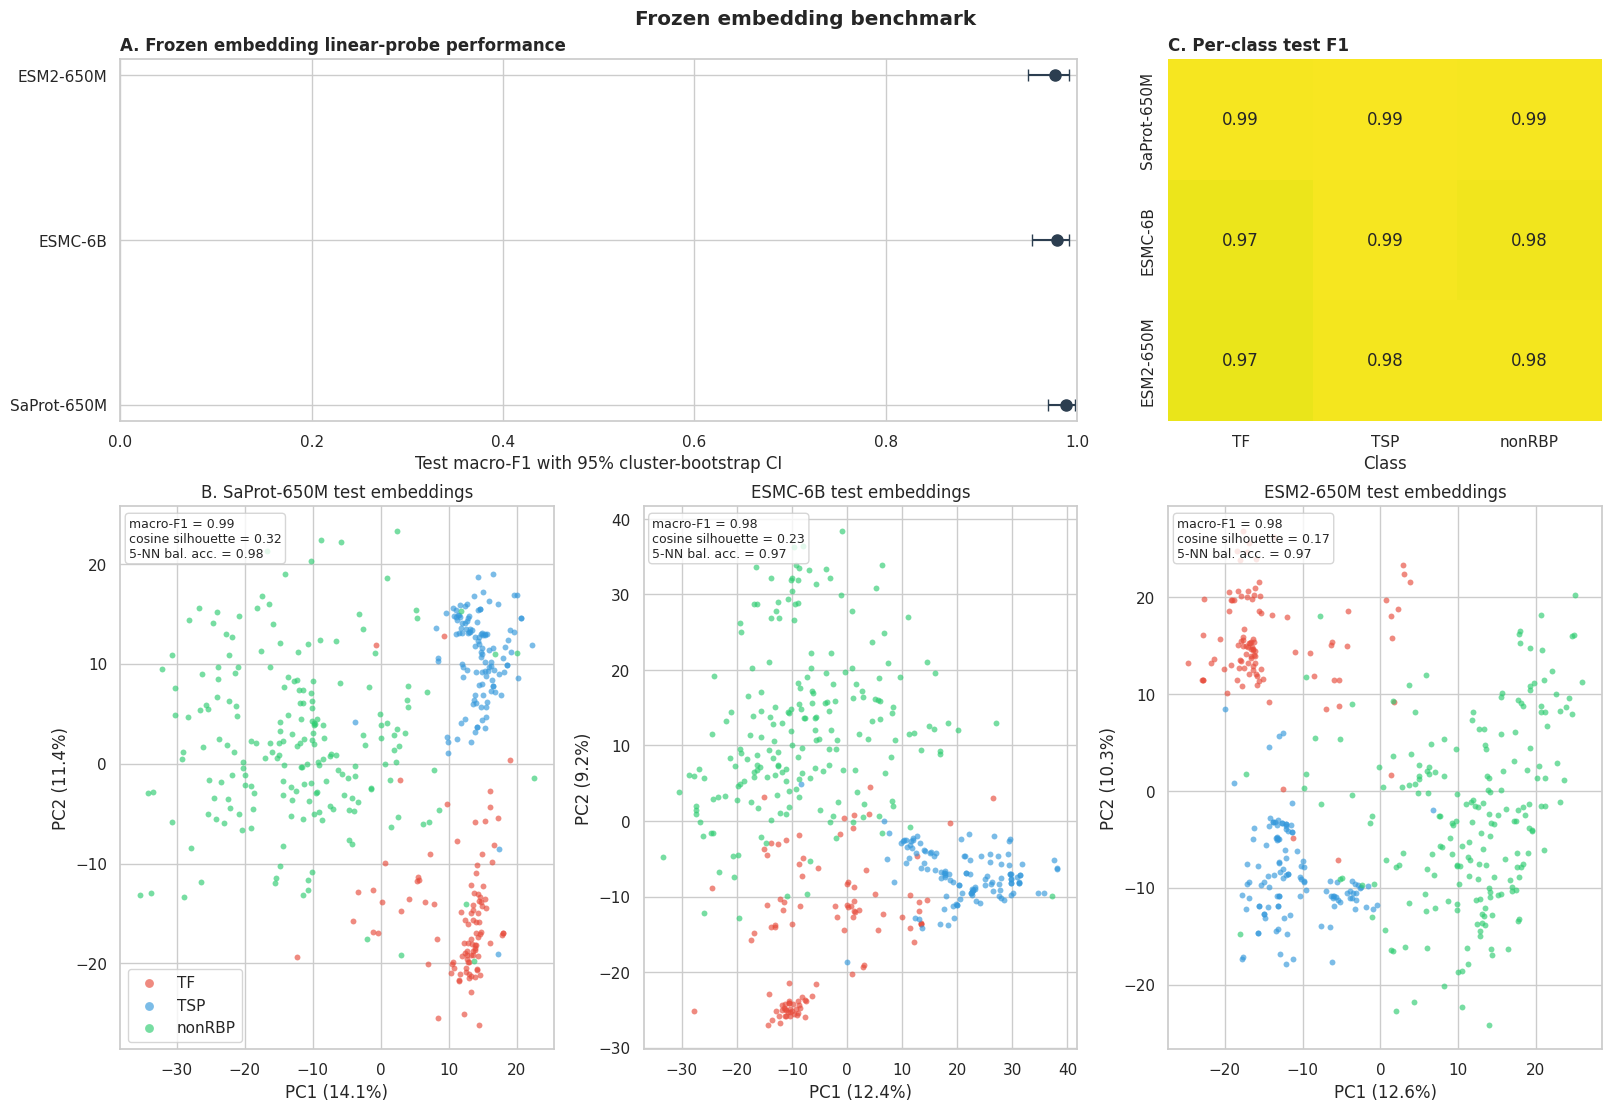

In [7]:
model_order = list(results["model"])
fig = plt.figure(figsize=(16, 11), constrained_layout=True)
grid = fig.add_gridspec(2, 3, height_ratios=[0.8, 1.2])

# A: Primary held-out metric
ax = fig.add_subplot(grid[0, :2])
plot_results = results.set_index("model").loc[model_order]
x = plot_results["macro_f1"].to_numpy()
xerr = np.vstack([
    x - plot_results["macro_f1_ci_low"].to_numpy(),
    plot_results["macro_f1_ci_high"].to_numpy() - x,
])
ax.errorbar(x, model_order, xerr=xerr, fmt="o", markersize=8, capsize=4, color="#2c3e50")
ax.set_xlabel("Test macro-F1 with 95% cluster-bootstrap CI")
ax.set_xlim(0, 1)
ax.set_title("A. Frozen embedding linear-probe performance", loc="left", fontweight="bold")

# C: Per-class F1
ax = fig.add_subplot(grid[0, 2])
f1_table = plot_results[[f"{label}_f1" for label in LABELS]].copy()
f1_table.columns = LABELS
sns.heatmap(f1_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", cbar=False, ax=ax)
ax.set_xlabel("Class")
ax.set_ylabel("")
ax.set_title("C. Per-class test F1", loc="left", fontweight="bold")

# B: Held-out PCA panels
split_lookup = split.set_index("id")["split"]
for column, model_name in enumerate(model_order):
    ax = fig.add_subplot(grid[1, column])
    bundle = bundles[model_name]
    ids = bundle["ids"]
    embeddings = bundle["embeddings"]
    row_splits = ids["id"].map(split_lookup)
    train_mask = row_splits.eq("train").to_numpy()
    test_mask = row_splits.eq("test").to_numpy()
    scaler = StandardScaler().fit(embeddings[train_mask])
    train_scaled = scaler.transform(embeddings[train_mask])
    test_scaled = scaler.transform(embeddings[test_mask])
    pca = PCA(n_components=2, random_state=42).fit(train_scaled)
    coordinates = pca.transform(test_scaled)
    test_labels = ids.loc[test_mask, "label"].to_numpy()
    for label in LABELS:
        label_mask = test_labels == label
        ax.scatter(
            coordinates[label_mask, 0], coordinates[label_mask, 1],
            s=18, alpha=0.65, linewidths=0, color=COLORS[label], label=label,
        )
    row = plot_results.loc[model_name]
    ax.text(
        0.02, 0.98,
        f"macro-F1 = {row['macro_f1']:.2f}\ncosine silhouette = {row['cosine_silhouette']:.2f}\n5-NN bal. acc. = {row['5nn_balanced_accuracy']:.2f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "#cccccc"},
    )
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    title_prefix = "B. " if column == 0 else ""
    ax.set_title(f"{title_prefix}{model_name} test embeddings")
    if column == 0:
        ax.legend(frameon=True, markerscale=1.5)

fig.suptitle("Frozen embedding benchmark", fontweight="bold")
fig.savefig(RESULTS_DIR / "embedding_benchmark_main.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "embedding_benchmark_main.pdf", bbox_inches="tight")
plt.show()

## Confusion matrices

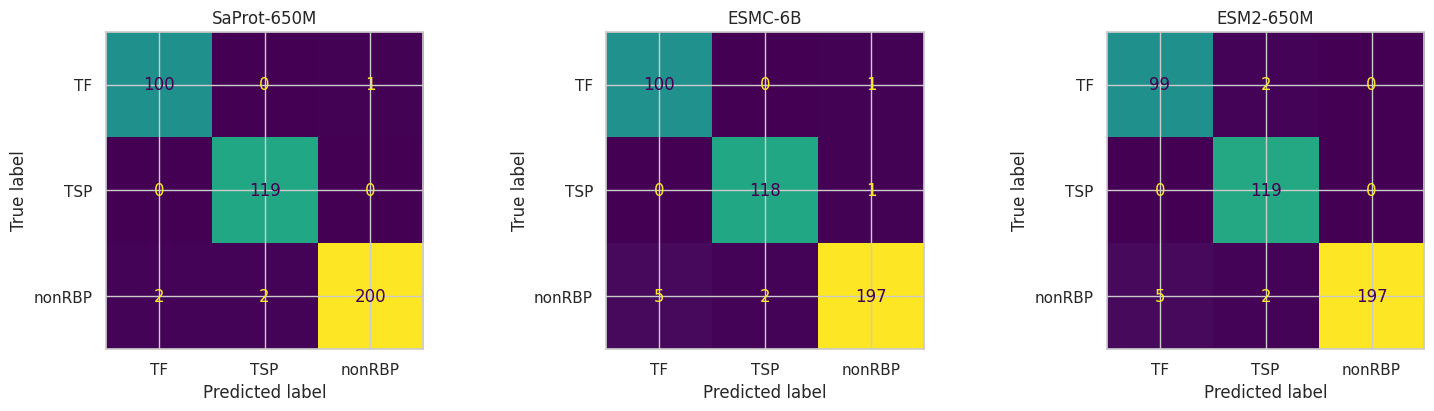

In [8]:
fig, axes = plt.subplots(1, len(model_order), figsize=(5 * len(model_order), 4), constrained_layout=True)
for ax, model_name in zip(np.atleast_1d(axes), model_order):
    frame = predictions[predictions["model"] == model_name]
    matrix = confusion_matrix(frame["label"], frame["prediction"], labels=LABELS)
    ConfusionMatrixDisplay(matrix, display_labels=LABELS).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)
fig.savefig(RESULTS_DIR / "embedding_benchmark_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()